In [1]:
import sys
# open3SPN2_HOME = '/Users/weilu/open3spn2/'
openAWSEM_HOME = '/home/sl206/Programs/openawsem'
# sys.path.insert(0,open3SPN2_HOME)
sys.path.insert(0,openAWSEM_HOME)

In [2]:
import pandas as pd
import numpy as np
import openmm
#import openmm

from functools import partial
import sys

import open3SPN2
import openawsem

In [3]:
system = "1lmb"

In [4]:
#Fix the system (adds missing atoms)
fix=open3SPN2.fixPDB(f"{system}.pdb")

In [5]:
#Create a table containing both the proteins and the DNA
complex_table=open3SPN2.pdb2table(fix)

# Create a single memory file
openawsem.create_single_memory(fix)

/home/sl206/.conda/envs/openmm8/lib/python3.12/site-packages/Bio/PDB/PDBParser.py:395: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 4071
  warnings.warn(


In [6]:
complex_table.to_csv('complex_table.csv', index=True)

In [7]:
#Generate a coarse-grained model of the DNA molecules
dna_atoms=open3SPN2.DNA.CoarseGrain(complex_table)

#Generate a coarse-grained model of the Protein molecules
protein_atoms=openawsem.Protein.CoarseGrain(complex_table)

/home/sl206/Programs/open3spn2/open3SPN2/ff3SPN2.py:452: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['mass'] = temp.element.replace(masses).astype(float)


In [8]:
dna_atoms.to_csv('dna_atoms.csv', index=True)

In [9]:
#Merge the models
Coarse=pd.concat([protein_atoms,dna_atoms],sort=False)
Coarse.index=range(len(Coarse))
Coarse['serial']=list(Coarse.index)

In [10]:
#Save the protein_sequence
openawsem.save_protein_sequence(Coarse,sequence_file='protein.seq')

/home/sl206/Programs/openawsem/openawsem/openAWSEM.py:140: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  protein_data['resID'] = resix.replace(dict(zip(res_unique, range(len(res_unique)))))


In [11]:
# Create a merged PDB
openawsem.writePDB(Coarse,f'{system}-clean.pdb')

In [14]:
# Defining X as GC * 22 + G
X = '' * 22

# Defining the sequences
bs_nfkbsite1 = 'A' + 'GGAAATTCCC' + 'T'

# Concatenating X + 1 + X
seq = X + bs_nfkbsite1 + X

# Printing the results
print("Result 1:", seq)

Result 1: AGGAAATTCCCT


In [15]:
dna=open3SPN2.DNA.fromSequence(seq,dna_type='B_curved')

/home/sl206/Programs/open3spn2/open3SPN2/ff3SPN2.py:452: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['mass'] = temp.element.replace(masses).astype(float)
/home/sl206/Programs/open3spn2/open3SPN2/ff3SPN2.py:452: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['mass'] = temp.element.replace(masses).astype(float)
/home/sl206/Programs/open3spn2/open3SPN2/ff3SPN2.py:452: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.i

In [16]:
dna.computeTopology(template_from_X3DNA=True)

/home/sl206/Programs/open3spn2/open3SPN2/ff3SPN2.py:452: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  temp['mass'] = temp.element.replace(masses).astype(float)


In [17]:
dna.atoms.to_csv('dna.csv', index=True)

In [18]:
import prody
selected_1 = pd.read_csv('dna.csv')

In [19]:
#print(len(selected))
#print(len(dna_atoms))
new_coord,transformation = prody.superpose(selected_1[['x', 'y', 'z']].values, dna_atoms[['x', 'y', 'z']].values)

In [20]:
# In[12]:


dna_superpose = dna.atoms.copy()
dna_superpose[['x','y','z']] = transformation.apply(dna.atoms[['x', 'y', 'z']].values)
dna_superpose['chainID']=dna_superpose['chainID'].replace({'A':'C','B':'D'})

In [21]:
#Merge the models
Coarse=pd.concat([protein_atoms,dna_superpose],sort=False)
Coarse.index=range(len(Coarse))
Coarse['serial']=list(Coarse.index)

In [22]:
#Save the protein_sequence
openawsem.save_protein_sequence(Coarse,sequence_file=f'protein.seq')

/home/sl206/Programs/openawsem/openawsem/openAWSEM.py:140: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  protein_data['resID'] = resix.replace(dict(zip(res_unique, range(len(res_unique)))))


In [23]:
# Create a merged PDB
openawsem.writePDB(Coarse,f'{system}-s1bs-clean.pdb')

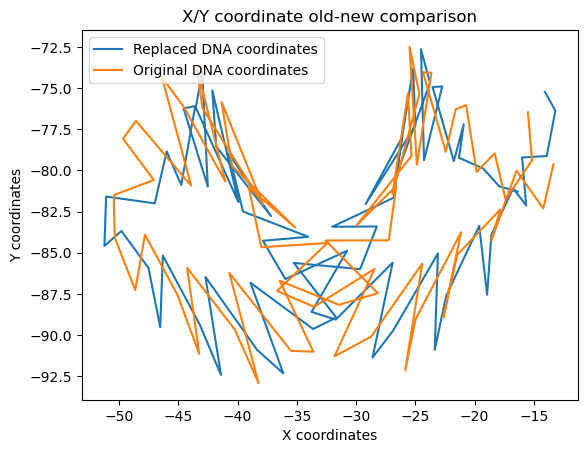

In [24]:
#Verification
import matplotlib.pyplot as plt

plt.plot(new_coord[:,0], new_coord[:,1], alpha=1, label="Replaced DNA coordinates")
plt.plot(dna_atoms['x'].values, dna_atoms['y'].values, alpha=1, label="Original DNA coordinates")
plt.legend()
plt.xlabel("X coordinates")
plt.ylabel("Y coordinates")
plt.title("X/Y coordinate old-new comparison")
plt.show()

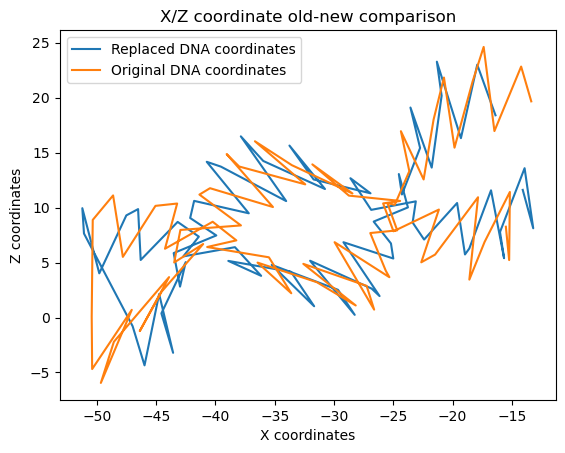

In [25]:
#Verification
import matplotlib.pyplot as plt

plt.plot(new_coord[:,0], new_coord[:,2], alpha=1, label="Replaced DNA coordinates")
plt.plot(dna_atoms['x'].values, dna_atoms['z'].values, alpha=1, label="Original DNA coordinates")
plt.legend()
plt.xlabel("X coordinates")
plt.ylabel("Z coordinates")
plt.title("X/Z coordinate old-new comparison")
plt.show()

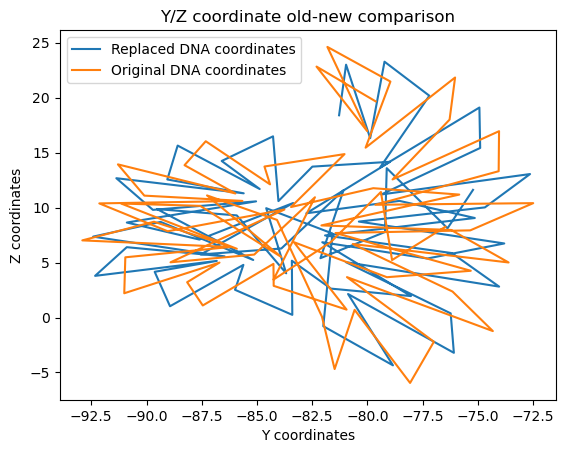

In [26]:
#Verification
import matplotlib.pyplot as plt

plt.plot(new_coord[:,1], new_coord[:,2], alpha=1, label="Replaced DNA coordinates")
plt.plot(dna_atoms['y'].values, dna_atoms['z'].values, alpha=1, label="Original DNA coordinates")
plt.legend()
plt.xlabel("Y coordinates")
plt.ylabel("Z coordinates")
plt.title("Y/Z coordinate old-new comparison")
plt.show()